In [161]:
# imports


import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [162]:
data = pd.read_csv('Datasets/smartwatches.csv')

data.drop_duplicates(inplace=True)

train_df = data.sample(frac=0.8, random_state=42)
test_df = data.drop(train_df.index)

train_df = train_df.reset_index()
test_df = test_df.reset_index()

In [163]:
data.shape, train_df.shape, test_df.shape

((450, 16), (360, 17), (90, 17))

In [164]:
train_df.head()

,index,Unnamed: 0,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,407,407,zebronics,2949.0,4199.0,29.768993,3.1,10.0,LEATHER fit-650,Oval,Black,Leather,Yes,NaN,Yes,2.7 inches,NaN
1,444,444,fire-boltt,6999.0,15999.0,56.253516,2.6,NaN,bsw020,Circle,Brown,Silicon,Yes,8.0,Yes,1.4 inches,NaN
2,117,117,fire-boltt,2499.0,11999.0,79.173264,4.1,1990.0,BSW070,NaN,NaN,NaN,Yes,8.0,Yes,1.9 inches,75g +
3,30,30,boat,1999.0,7990.0,74.981227,3.6,827.0,NaN,NaN,NaN,NaN,NaN,8.0,Yes,NaN,75g +
4,415,415,fire-boltt,2299.0,5999.0,61.676946,2.5,24.0,NINJA PRO MAX,Square,Blue,Silicon,Yes,22.0,Yes,1.6 inches,NaN


In [165]:
train_df.drop(['index','Unnamed: 0'], axis=1, inplace=True)
train_df.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight
0,zebronics,2949.0,4199.0,29.768993,3.1,10.0,LEATHER fit-650,Oval,Black,Leather,Yes,NaN,Yes,2.7 inches,NaN
1,fire-boltt,6999.0,15999.0,56.253516,2.6,NaN,bsw020,Circle,Brown,Silicon,Yes,8.0,Yes,1.4 inches,NaN
2,fire-boltt,2499.0,11999.0,79.173264,4.1,1990.0,BSW070,NaN,NaN,NaN,Yes,8.0,Yes,1.9 inches,75g +
3,boat,1999.0,7990.0,74.981227,3.6,827.0,NaN,NaN,NaN,NaN,NaN,8.0,Yes,NaN,75g +
4,fire-boltt,2299.0,5999.0,61.676946,2.5,24.0,NINJA PRO MAX,Square,Blue,Silicon,Yes,22.0,Yes,1.6 inches,NaN


In [166]:
train_df['Display Size'].isna().sum()

np.int64(27)

In [167]:
train_df['Display Size'].value_counts().count()

np.int64(34)

In [168]:
train_df['Display Size'].fillna('0.0 inches', inplace=True)
train_df['Display Size'].isna().sum()

C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2060797571.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Display Size'].fillna('0.0 inches', inplace=True)


np.int64(0)

In [169]:
train_df['Display Size'] = train_df['Display Size'].apply(lambda x: float(x.split()[0]))

# float('0.0 inches'.split()[0])

In [170]:
train_df['Display Size'].replace(0.0, np.nan, inplace=True)

train_df['Display Size'].isna().sum()

C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2734313038.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Display Size'].replace(0.0, np.nan, inplace=True)


np.int64(28)

In [171]:
train_df['Weight'].value_counts()

Weight
20 - 35 g    63
75g +        58
35 - 50 g    45
<= 20 g      30
50 - 75 g    15
Name: count, dtype: int64

In [172]:
re.findall('\d+', '20 - 35 g')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\3142025644.py:1: SyntaxWarning: invalid escape sequence '\d'
  re.findall('\d+', '20 - 35 g')


['20', '35']

In [173]:
cal = sum([int(x) for x in re.findall('\d+', '20 - 35 g')]) / 2

train_df['Weight'].replace('20 - 35 g', cal, inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2181387236.py:1: SyntaxWarning: invalid escape sequence '\d'
  cal = sum([int(x) for x in re.findall('\d+', '20 - 35 g')]) / 2
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2181387236.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('20 - 35 g', cal, inplace=True)


In [174]:
cal = sum([int(x) for x in re.findall('\d+', '35 - 50 g')]) / 2

train_df['Weight'].replace('35 - 50 g', cal, inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\4170158647.py:1: SyntaxWarning: invalid escape sequence '\d'
  cal = sum([int(x) for x in re.findall('\d+', '35 - 50 g')]) / 2
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\4170158647.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('35 - 50 g', cal, inplace=True)


In [175]:
cal = sum([int(x) for x in re.findall('\d+', '50 - 75 g')]) / 2

train_df['Weight'].replace('50 - 75 g', cal, inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2723606332.py:1: SyntaxWarning: invalid escape sequence '\d'
  cal = sum([int(x) for x in re.findall('\d+', '50 - 75 g')]) / 2
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\2723606332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('50 - 75 g', cal, inplace=True)


In [176]:
train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\3271034506.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\3271034506.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('75g +', float(re.findall('\d+', '75g +')[0]), inplace=True)


In [177]:
train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\1289372860.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)
C:\Users\bhave\AppData\Local\Temp\ipykernel_31368\1289372860.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Weight'].replace('<= 20 g', float(re.findall('\d+', '<= 20 g')[0]), inplace=True)
C:\Users\bhave\AppData

In [178]:
train_df['Weight'].value_counts()

Weight
27.5    63
75.0    58
42.5    45
20.0    30
62.5    15
Name: count, dtype: int64

In [179]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                360 non-null    object 
 1   Current Price        354 non-null    float64
 2   Original Price       304 non-null    float64
 3   Discount Percentage  304 non-null    float64
 4   Rating               356 non-null    float64
 5   Number OF Ratings    315 non-null    float64
 6   Model Name           330 non-null    object 
 7   Dial Shape           260 non-null    object 
 8   Strap Color          260 non-null    object 
 9   Strap Material       304 non-null    object 
 10  Touchscreen          329 non-null    object 
 11  Battery Life (Days)  330 non-null    float64
 12  Bluetooth            355 non-null    object 
 13  Display Size         332 non-null    float64
 14  Weight               211 non-null    float64
dtypes: float64(8), object(7)
memory usage: 4

In [180]:
train_df['Discount Price'] = train_df['Original Price'] * (-train_df['Discount Percentage']) / 100

train_df.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Discount Price
0,zebronics,2949.0,4199.0,29.768993,3.1,10.0,LEATHER fit-650,Oval,Black,Leather,Yes,NaN,Yes,2.7,NaN,-1250.000000
1,fire-boltt,6999.0,15999.0,56.253516,2.6,NaN,bsw020,Circle,Brown,Silicon,Yes,8.0,Yes,1.4,NaN,-8999.999999
2,fire-boltt,2499.0,11999.0,79.173264,4.1,1990.0,BSW070,NaN,NaN,NaN,Yes,8.0,Yes,1.9,75.0,-9500.000000
3,boat,1999.0,7990.0,74.981227,3.6,827.0,NaN,NaN,NaN,NaN,NaN,8.0,Yes,NaN,75.0,-5991.000000
4,fire-boltt,2299.0,5999.0,61.676946,2.5,24.0,NINJA PRO MAX,Square,Blue,Silicon,Yes,22.0,Yes,1.6,NaN,-3700.000000


In [181]:
train_df.drop(['Discount Percentage'], axis=1, inplace=True)

#### Numerical Data

In [182]:
numerical_col = [feature for feature in train_df.columns if train_df[feature].dtype == 'float64']
numerical_col

['Current Price',
 'Original Price',
 'Rating',
 'Number OF Ratings',
 'Battery Life (Days)',
 'Display Size',
 'Weight',
 'Discount Price']

In [183]:
train_df[numerical_col].head()

,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Display Size,Weight,Discount Price
0,2949.0,4199.0,3.1,10.0,NaN,2.7,NaN,-1250.000000
1,6999.0,15999.0,2.6,NaN,8.0,1.4,NaN,-8999.999999
2,2499.0,11999.0,4.1,1990.0,8.0,1.9,75.0,-9500.000000
3,1999.0,7990.0,3.6,827.0,8.0,NaN,75.0,-5991.000000
4,2299.0,5999.0,2.5,24.0,22.0,1.6,NaN,-3700.000000


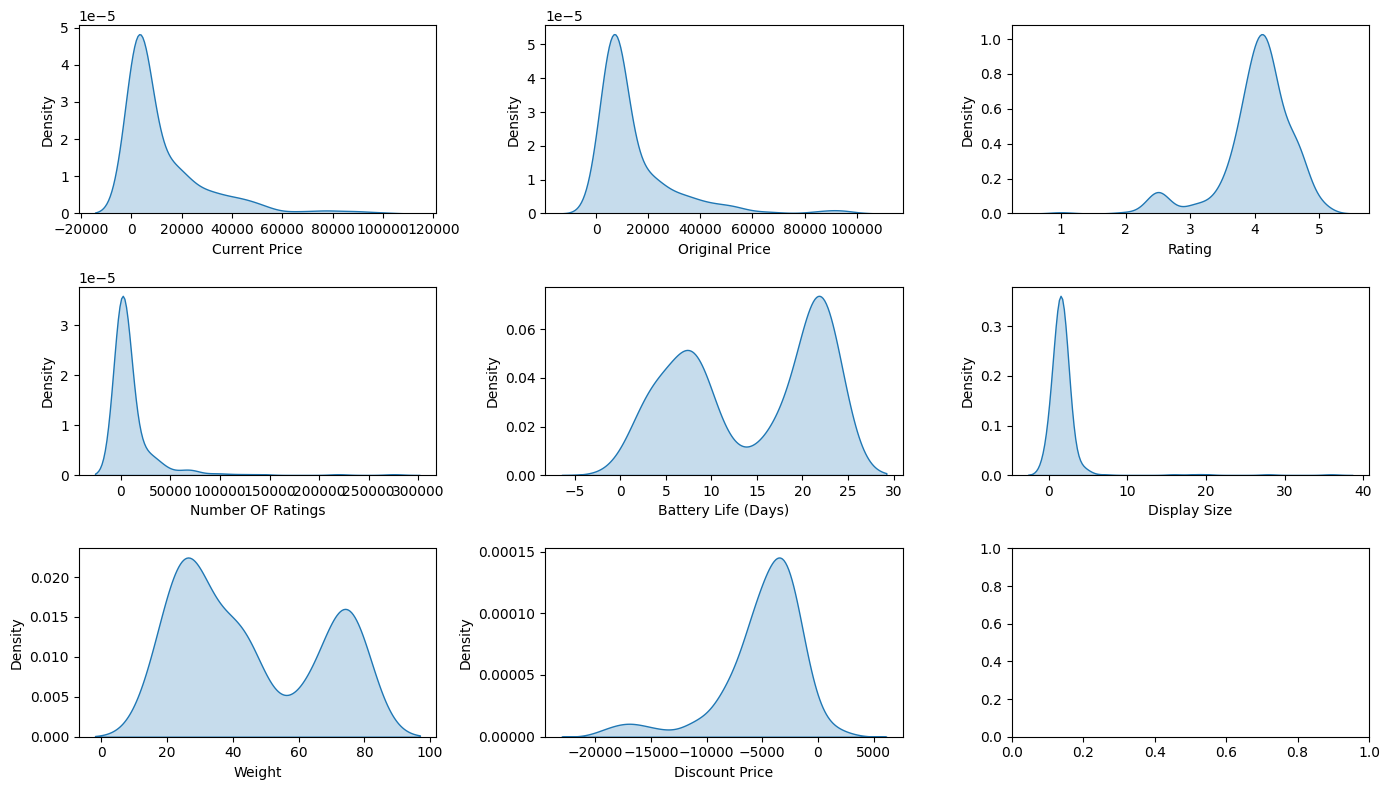

In [184]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 8))

for i, column in enumerate(numerical_col):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.kdeplot(data=train_df[column], ax=ax, fill=True)

fig.tight_layout()
plt.show()

# Skewness replace nan with median 

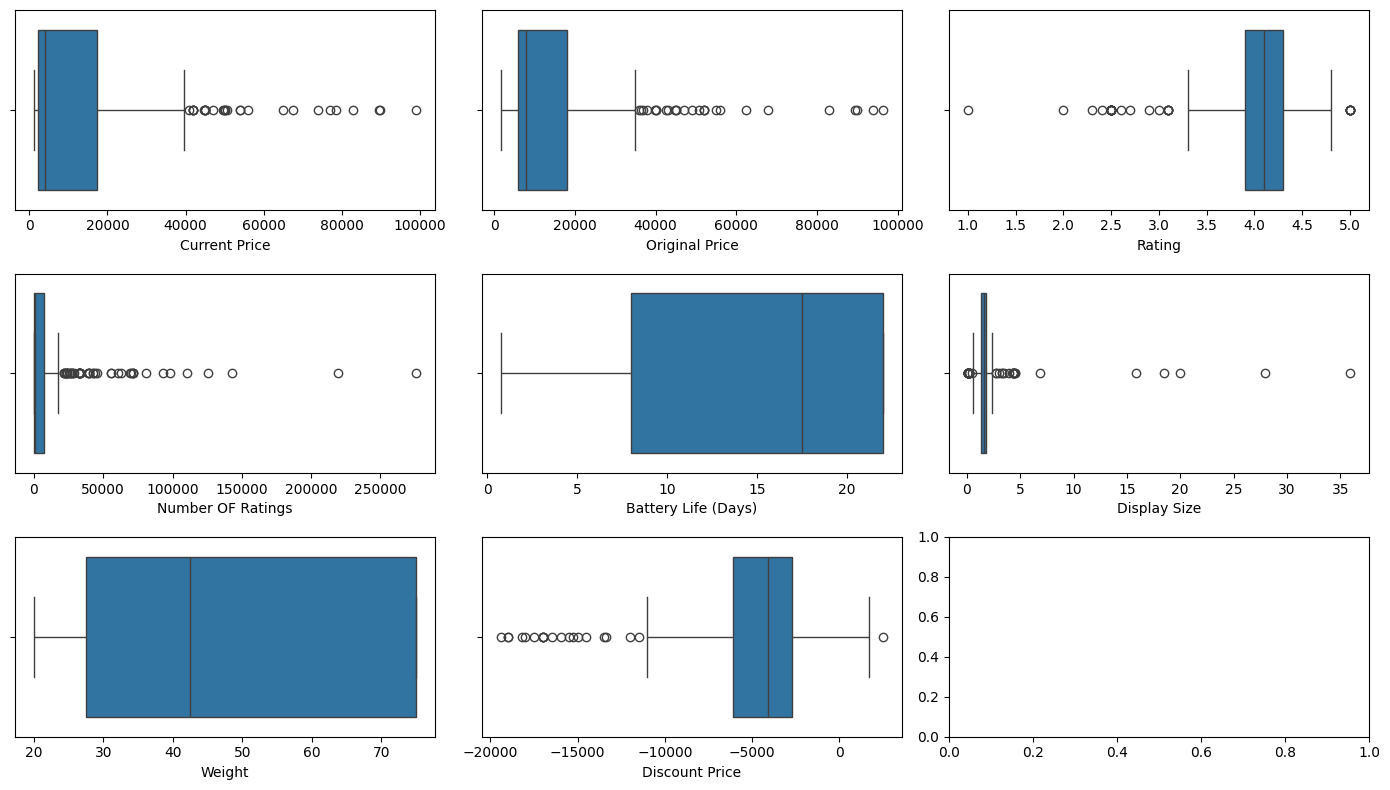

In [185]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 8))

for i, column in enumerate(numerical_col):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(x=train_df[column], ax=ax)

fig.tight_layout()
plt.show()

In [186]:
train_df.columns
train_df.shape

(360, 15)

In [187]:
# Remove Outlier

def remove_outliers_IQR (data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col] > lower_bound) & (data[col] < upper_bound)]

# col having outliers
important_col = ['Current Price', 'Original Price', 'Rating', 'Number OF Ratings', 'Display Size']

for col in important_col:
    train_df = remove_outliers_IQR(train_df, col)

In [188]:
train_df.head()

,Brand,Current Price,Original Price,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Discount Price
2,fire-boltt,2499.0,11999.0,4.1,1990.0,BSW070,NaN,NaN,NaN,Yes,8.0,Yes,1.9,75.0,-9500.0
5,noise,2499.0,6999.0,4.3,3944.0,"ColorFit Loop Advanced BT Calling with 1.85"" d...",Square,Grey,Silicon,Yes,22.0,Yes,1.9,NaN,-4500.0
6,dizo,3499.0,5999.0,4.2,1785.0,Watch D Talk 1.8 display with calling&7 day ba...,Rectangle,Grey,Silicon,Yes,22.0,Yes,1.8,75.0,-2500.0
12,dizo,2126.0,5999.0,3.7,18.0,NaN,NaN,NaN,NaN,Yes,8.0,Yes,1.9,27.5,-3873.0
19,honor,11499.0,18999.0,3.9,406.0,MUS-B19,NaN,NaN,NaN,Yes,12.5,Yes,1.4,42.5,-7500.0


In [192]:
# Imputing the null values

import numpy as np
import pandas as pd
import re

# 1. Clean 'Display Size' to numeric (e.g. "1.4 inches" -> 1.4)
def clean_display_size(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'[\d.]+', str(val))
    return float(match.group()) if match else np.nan

train_df['Display Size (Inches)'] = train_df['Display Size'].apply(clean_display_size)

# 2. Clean 'Weight' to numeric
def clean_weight(val):
    if pd.isna(val):
        return np.nan
    nums = [float(x) for x in re.findall(r'\d+', str(val))]
    if len(nums) == 2:      # '20 - 35 g' -> midpoint (27.5)
        return sum(nums) / 2
    elif len(nums) == 1:    # '75g +' or '<= 20 g' -> 75.0 or 20.0
        return nums[0]
    return np.nan

train_df['Weight (g)'] = train_df['Weight'].apply(clean_weight)

# Drop redundant old raw columns
train_df.drop(columns=['Weight', 'Display Size'], inplace=True, errors='ignore')

# Impute Model Name (or drop it)
train_df['Model Name'] = train_df['Model Name'].fillna('Unknown')


# 3. Impute Numerical Features with Groupby (Brand Median) -> Global Fallback
numerical_to_impute = ['Display Size (Inches)', 'Weight (g)', 'Battery Life (Days)', 'Rating', 'Number OF Ratings']

for col in numerical_to_impute:
    # Calculate median per brand
    brand_median = train_df.groupby('Brand')[col].transform('median')
    # Fill with brand median first, then global median if still NaN
    train_df[col] = train_df[col].fillna(brand_median).fillna(train_df[col].median())

# 4. Impute Categorical Features (Dial Shape, Strap Material, etc.)
# If missing rate is high (like Dial Shape ~27%), filling with 'Unknown' or Brand Mode is best:
categorical_to_impute = ['Dial Shape', 'Strap Material', 'Strap Color', 'Touchscreen', 'Bluetooth']

for col in categorical_to_impute:
    # Option A: Replace missing with 'Unknown' (avoids fabricating unknown specs)
    train_df[col] = train_df[col].fillna('Unknown')


In [193]:
train_df.isna().sum()

Brand                    0
Current Price            0
Original Price           0
Rating                   0
Number OF Ratings        0
Model Name               0
Dial Shape               0
Strap Color              0
Strap Material           0
Touchscreen              0
Battery Life (Days)      0
Bluetooth                0
Discount Price           0
Display Size (Inches)    0
Weight (g)               0
dtype: int64

In [196]:
numerical_col

['Current Price',
 'Original Price',
 'Rating',
 'Number OF Ratings',
 'Battery Life (Days)',
 'Display Size',
 'Weight',
 'Discount Price']

In [201]:
# train_df[numerical_col]

# Re-fetch the numerical columns from the updated dataframe
numerical_col = train_df.select_dtypes(include=['float64', 'int64', 'number']).columns.tolist()

# Now view the numerical columns
train_df[numerical_col].head()


,Current Price,Original Price,Rating,Number OF Ratings,Battery Life (Days),Discount Price,Display Size (Inches),Weight (g)
2,2499.0,11999.0,4.1,1990.0,8.0,-9500.0,1.9,37.5
5,2499.0,6999.0,4.3,3944.0,22.0,-4500.0,1.9,23.5
6,3499.0,5999.0,4.2,1785.0,22.0,-2500.0,1.8,37.5
12,2126.0,5999.0,3.7,18.0,8.0,-3873.0,1.9,16.0
19,11499.0,18999.0,3.9,406.0,12.5,-7500.0,1.4,23.5


In [202]:
train_df.shape

(143, 15)